In [1]:
import pandas as pd

# Load master data and instagram posts data
master_data = pd.read_csv('../data/processed/master_data.csv')
instagram_data = pd.read_csv('../data/raw/instagram_posts.csv')


# Convert 'Date' columns to datetime for both datasets
master_data['Date'] = pd.to_datetime(master_data['Date'])
instagram_data['date'] = pd.to_datetime(instagram_data['date'])

# Merge the two datasets on Date (master_data with instagram_posts)
merged_df = pd.merge(master_data, instagram_data[['date', 'shortcode']], left_on='Date', right_on='date', how='left')

# Create the "Posted" column (1 if there is a post, 0 if not)
merged_df['Posted_today'] = merged_df['shortcode'].notna().astype(int)

# Fill NaN in 'shortcode' column, indicating no post
merged_df['shortcode'] = merged_df['shortcode'].fillna('No Post')

# Create lag features for the post days
merged_df['Posted_yesterday'] = merged_df['Posted_today'].shift(1).fillna(0)
merged_df['Posted_2daysago'] = merged_df['Posted_today'].shift(2).fillna(0)

# Drop the 'shortcode' column as it's no longer needed
merged_df.drop(columns=['shortcode'], inplace=True)

# Drop the 'date' column as it's redundant
merged_df.drop(columns=['date'], inplace=True)

# Inspect the final dataframe again
print(merged_df.head())

        Date  Sessions Net Sales  Likes  Comments Instagram Post?  \
0 2021-05-31       0.0     £0.00    0.0       0.0              No   
1 2021-06-01       0.0     £0.00    0.0       0.0              No   
2 2021-06-02       0.0     £0.00    0.0       0.0              No   
3 2021-06-03       0.0     £0.00    0.0       0.0              No   
4 2021-06-04       0.0     £0.00    0.0       0.0              No   

   Posted_today  Posted_yesterday  Posted_2daysago  
0             0               0.0              0.0  
1             0               0.0              0.0  
2             0               0.0              0.0  
3             0               0.0              0.0  
4             0               0.0              0.0  


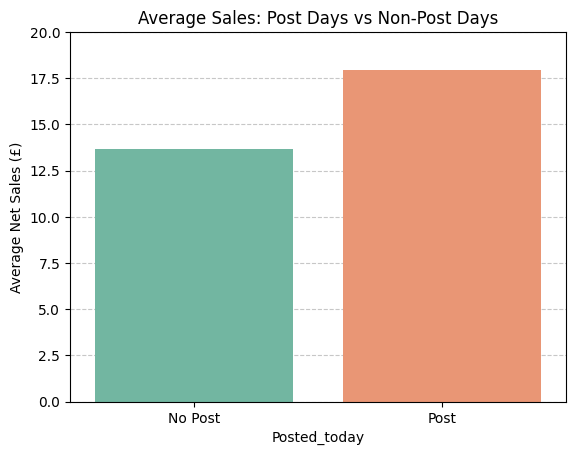

<Figure size 640x480 with 0 Axes>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Clean the Net Sales column
merged_df['Net Sales'] = (
    merged_df['Net Sales']
    .astype(str)  # Convert everything to string first
    .str.replace('£', '', regex=False)  # Remove £ symbol
    .str.replace(',', '', regex=False)  # Remove thousands separators if any
    .replace('nan', '0')  # Handle NaN values
    .astype(float)  # Convert to numeric
)

merged_df['Posted_today'] = merged_df['Posted_today'].astype(int)

sns.barplot(
    data=merged_df, 
    x='Posted_today', 
    y='Net Sales', 
    hue='Posted_today', 
    palette='Set2',
    errorbar=None,
    legend=False  
)

plt.xticks([0, 1], ['No Post', 'Post'])
plt.ylabel('Average Net Sales (£)')
plt.title('Average Sales: Post Days vs Non-Post Days')
plt.ylim(0, 20)
plt.gca().set_axisbelow(True)
plt.grid(axis='y', linestyle='--', alpha=0.7)  
plt.show()

plt.savefig('../visuals/avg_sales_post_days_vs_non_post_days.png', 
            dpi=300, 
            bbox_inches='tight',
            facecolor='white') 




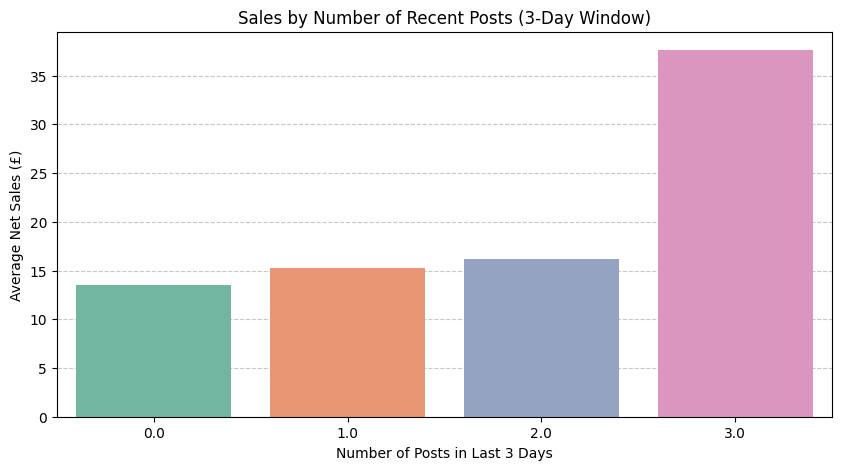

In [ ]:
# Include today in the 3-day post sum
merged_df['Post_Rolling'] = merged_df['Posted_today'].rolling(window=3).sum()

# Drop any rows with NaN in Post_Rolling
merged_df = merged_df.dropna(subset=['Post_Rolling'])

# Group by number of posts in the 3-day window and get average Net Sales
rolling_impact = merged_df.groupby('Post_Rolling')['Net Sales'].mean()

# Convert to DataFrame for plotting
rolling_impact_df = rolling_impact.reset_index()
rolling_impact_df.columns = ['Post_Rolling', 'Net Sales']

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(
    data=rolling_impact_df,
    x='Post_Rolling',
    y='Net Sales',
    hue='Post_Rolling',
    palette='Set2',
    legend=False
)

plt.title('Sales by Number of Recent Posts (3-Day Window)')
plt.xlabel('Number of Posts in Last 3 Days')
plt.ylabel('Average Net Sales (£)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().set_axisbelow(True)
plt.show()

# Save the visualization
plt.savefig('../visuals/sales_by_recent_posts.png', dpi=300, bbox_inches='tight')

In [3]:
# Recalculate the rolling post sum (include today in window)
merged_df['Post_Rolling'] = merged_df['Posted_today'].rolling(window=3).sum()

# Filter for rows where there were 3 posts in 3 days
three_post_streaks = merged_df[merged_df['Post_Rolling'] == 3]

# Display the relevant dates
print(three_post_streaks[['Date', 'Posted_today', 'Post_Rolling']])

# Get indices where Post_Rolling == 3
indices = three_post_streaks.index

# Loop through and print the 3-day windows
for idx in indices:
    print("\n--- 3-day Post Streak ---")
    print(merged_df.loc[idx-2:idx, ['Date', 'Posted_today']])




           Date  Posted_today  Post_Rolling
71   2021-08-09             1           3.0
296  2022-03-22             1           3.0
297  2022-03-23             1           3.0
548  2022-11-28             1           3.0
912  2023-11-26             1           3.0
920  2023-12-03             1           3.0
921  2023-12-04             1           3.0
1138 2024-07-08             1           3.0

--- 3-day Post Streak ---
         Date  Posted_today
69 2021-08-07             1
70 2021-08-08             1
71 2021-08-09             1

--- 3-day Post Streak ---
          Date  Posted_today
294 2022-03-20             1
295 2022-03-21             1
296 2022-03-22             1

--- 3-day Post Streak ---
          Date  Posted_today
295 2022-03-21             1
296 2022-03-22             1
297 2022-03-23             1

--- 3-day Post Streak ---
          Date  Posted_today
546 2022-11-26             1
547 2022-11-27             1
548 2022-11-28             1

--- 3-day Post Streak ---
         